## Chapter 2 of *Linear Models with R* (3e, 2025)

In [1]:
from hea import data
from hea.R import *
from hea.plot import *
from hea.models import lm

### 2.6

In [2]:
gala = data("gala", package="faraway")
head(gala)

rowname,Species,Endemics,Area,Elevation,Nearest,Scruz,Adjacent
str,i64,i64,f64,i64,f64,f64,f64
"""Baltra""",58,23,25.09,346,0.6,0.6,1.84
"""Bartolome""",31,21,1.24,109,0.6,26.3,572.33
"""Caldwell""",3,3,0.21,114,2.8,58.7,0.78
"""Champion""",25,9,0.1,46,1.9,47.4,0.18
"""Coamano""",2,1,0.05,77,1.9,1.9,903.82
"""Daphne.Major""",18,11,0.34,119,8.0,8.0,1.84


In [3]:
m0 = lm("Species ~ Area + Elevation + Nearest + Scruz + Adjacent", gala)
summary(m0)

Formula: Species ~ Area + Elevation + Nearest + Scruz + Adjacent

Residuals:
     Min      1Q Median     3Q     Max
-111.679 -34.898 -7.862 33.460 182.584

Coefficients:
              Estimate  Std. Error   CI[2.5%]  CI[97.5]%    t value  Pr(>|t|)
(Intercept)   7.068221   19.154198  -32.46410   46.60054   0.369017  0.715351
Area         -0.023938    0.022422   -0.07022    0.02234  -1.067611  0.296318
Elevation     0.319465    0.053663    0.20871    0.43022   5.953188  3.82e-06  ***
Nearest       0.009144    1.054136   -2.16649    2.18477   0.008674  0.993151
Scruz        -0.240524    0.215402   -0.68509    0.20404  -1.116628  0.275208
Adjacent     -0.074805    0.017700   -0.11134   -0.03827  -4.226217  0.000297  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 6, Residual SE = 60.975 on 24 DF
R-Squared = 0.7658, adjusted R-Squared = 0.7171
F-statistics = 15.6994 on 5 and 24 DF, p-value: 6.837893e-07

Log Likelihood = -162.5350, AIC = 339.0700, BIC = 34

### 2.10

In [4]:
anscombe = data("anscombe")
head(anscombe)

x1,x2,x3,x4,y1,y2,y3,y4
i64,i64,i64,i64,f64,f64,f64,f64
10,10,10,8,8.04,9.14,7.46,6.58
8,8,8,8,6.95,8.14,6.77,5.76
13,13,13,8,7.58,8.74,12.74,7.71
9,9,9,8,8.81,8.77,7.11,8.84
11,11,11,8,8.33,9.26,7.81,8.47
14,14,14,8,9.96,8.1,8.84,7.04


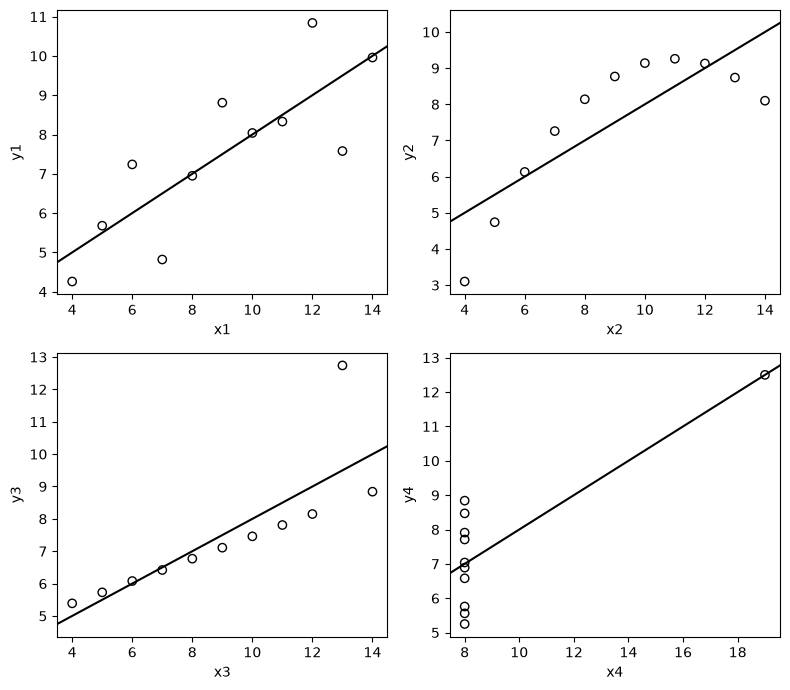

In [5]:
acn = anscombe.columns

with par(mfrow=(2, 2)):
    for i in range(4):
        plot(
            anscombe[acn[i]],
            anscombe[acn[i + 4]],
            xlab=acn[i],
            ylab=acn[i + 4],
        )
        lmod = lm(f"{acn[i + 4]} ~ {acn[i]}", data=anscombe)
        abline(lmod)

### 2.12

In [6]:
odor = data("odor", package="faraway")
odor

odor,temp,gas,pack
i64,i64,i64,i64
66,-1,-1,0
39,1,-1,0
43,-1,1,0
49,1,1,0
58,-1,0,-1
…,…,…,…
43,0,-1,1
-22,0,1,1
-31,0,0,0


In [7]:
m1 = lm("odor ~ temp + gas + pack", odor)
summary(m1, cor=True)

Formula: odor ~ temp + gas + pack

Residuals:
    Min      1Q Median     3Q    Max
-50.200 -17.137  1.175 20.300 62.925

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    15.200       9.298    -5.265     35.665   1.6347     0.130
temp          -12.125      12.732   -40.148     15.898  -0.9523     0.361
gas           -17.000      12.732   -45.023     11.023  -1.3352     0.209
pack          -21.375      12.732   -49.398      6.648  -1.6788     0.121
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 4, Residual SE = 36.012 on 11 DF
R-Squared = 0.3337, adjusted R-Squared = 0.1519
F-statistics = 1.8361 on 3 and 11 DF, p-value: 0.20

Log Likelihood = -72.7155, AIC = 155.4310, BIC = 158.9713

Correlation of Coefficients:
     (Intercept) temp  gas
temp -0.00
gas  -0.00       -0.00
pack  0.00        0.00  0.00

In [8]:
from hea import session_info

session_info()

Python version 3.13.11 (CPython)
Platform: arm64-darwin25.4.0
Running under: macOS 26.4.1

BLAS:   accelerate
LAPACK: accelerate

locale: C.UTF-8

time zone: CEST

hea version 0.1.9

attached packages:
[1] IPython_9.14.1    hea_0.1.9         matplotlib_3.11.0 numpy_2.5.0
[5] pandas_3.0.3      polars_1.41.2     pyarrow_24.0.0    pytest_9.1.1
[9] scipy_1.18.0

loaded via a namespace (and not attached):
 [1] Cython_3.2.9             PIL_12.2.0               appnope_0.1.4
 [4] argparse_1.1             asttokens_3.0.1          charset_normalizer_3.4.7
 [7] comm_0.2.3               csv_1.0                  ctypes_1.1.0
[10] cycler_0.12.1            cython_3.2.9             dateutil_2.9.0.post0
[13] debugpy_1.8.21           decimal_1.70             decorator_5.3.1
[16] defusedxml_0.7.1         executing_2.2.1          fontTools_4.63.0
[19] ipaddress_1.0            ipykernel_7.3.0          jedi_0.20.0
[22] json_2.0.9               jupyter_client_8.9.1     jupyter_core_5.9.1
[25] kiwisolver_1.5